# Claim-Sentinel EDA
Explore claims + policyholders from MySQL before building the fraud model.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv

In [2]:

load_dotenv()
DB_USER = os.getenv("DB_USER")
DB_PASS = quote_plus(os.getenv("DB_PASS"))
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_NAME = os.getenv("DB_NAME", "claim_sentinel")
engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}")

claims = pd.read_sql("SELECT * FROM claims", engine)
policyholders = pd.read_sql("SELECT * FROM policyholders", engine)
df = claims.merge(policyholders, on="policy_number")
df.shape

(1000, 42)

In [3]:
df.head()

,claim_id,policy_number,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,...,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital_gains,capital_loss
0,CLM-00001,521585,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,...,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0
1,CLM-00002,342868,2015-01-21,Vehicle Theft,None,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,...,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0
2,CLM-00003,687698,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,...,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0
3,CLM-00004,227811,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,...,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400
4,CLM-00005,367455,2015-02-17,Vehicle Theft,None,Minor Damage,None,NY,Arlington,3041 3rd Ave,...,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000


## Class balance (fraud_reported)

In [4]:
df['fraud_reported'].value_counts(normalize=True)


fraud_reported
N    0.753
Y    0.247
Name: proportion, dtype: float64

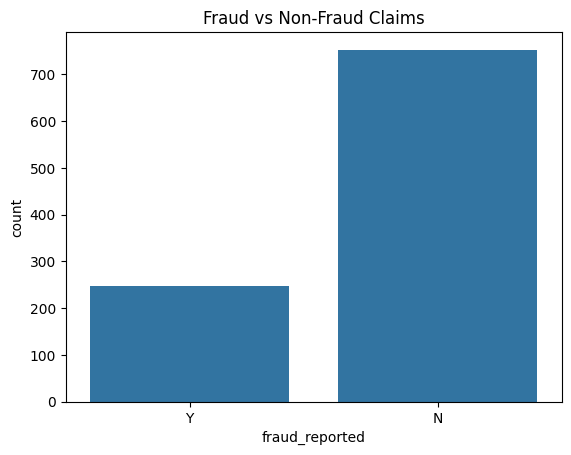

In [5]:
sns.countplot(data=df, x='fraud_reported')
plt.title('Fraud vs Non-Fraud Claims')
plt.show()

## Fraud rate by incident severity / type

In [6]:
pd.crosstab(df['incident_severity'], df['fraud_reported'], normalize='index')

fraud_reported,N,Y
incident_severity,,
Major Damage,0.394928,0.605072
Minor Damage,0.892655,0.107345
Total Loss,0.871429,0.128571
Trivial Damage,0.933333,0.066667


In [7]:
pd.crosstab(df['incident_type'], df['fraud_reported'], normalize='index')

fraud_reported,N,Y
incident_type,,
Multi-vehicle Collision,0.727924,0.272076
Parked Car,0.904762,0.095238
Single Vehicle Collision,0.709677,0.290323
Vehicle Theft,0.914894,0.085106


## Claim amount distribution: fraud vs non-fraud

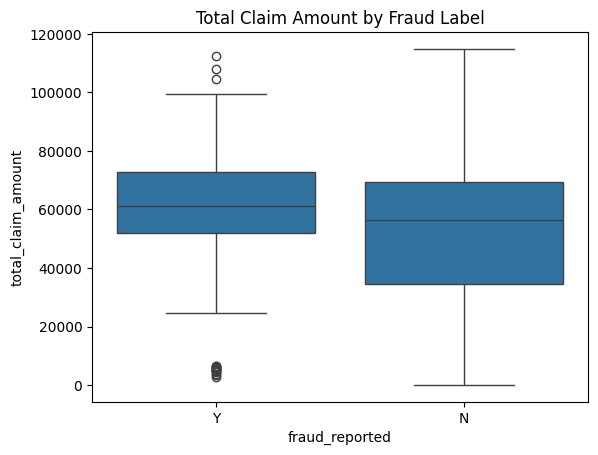

In [8]:
sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount')
plt.title('Total Claim Amount by Fraud Label')
plt.show()

## Numeric feature correlations

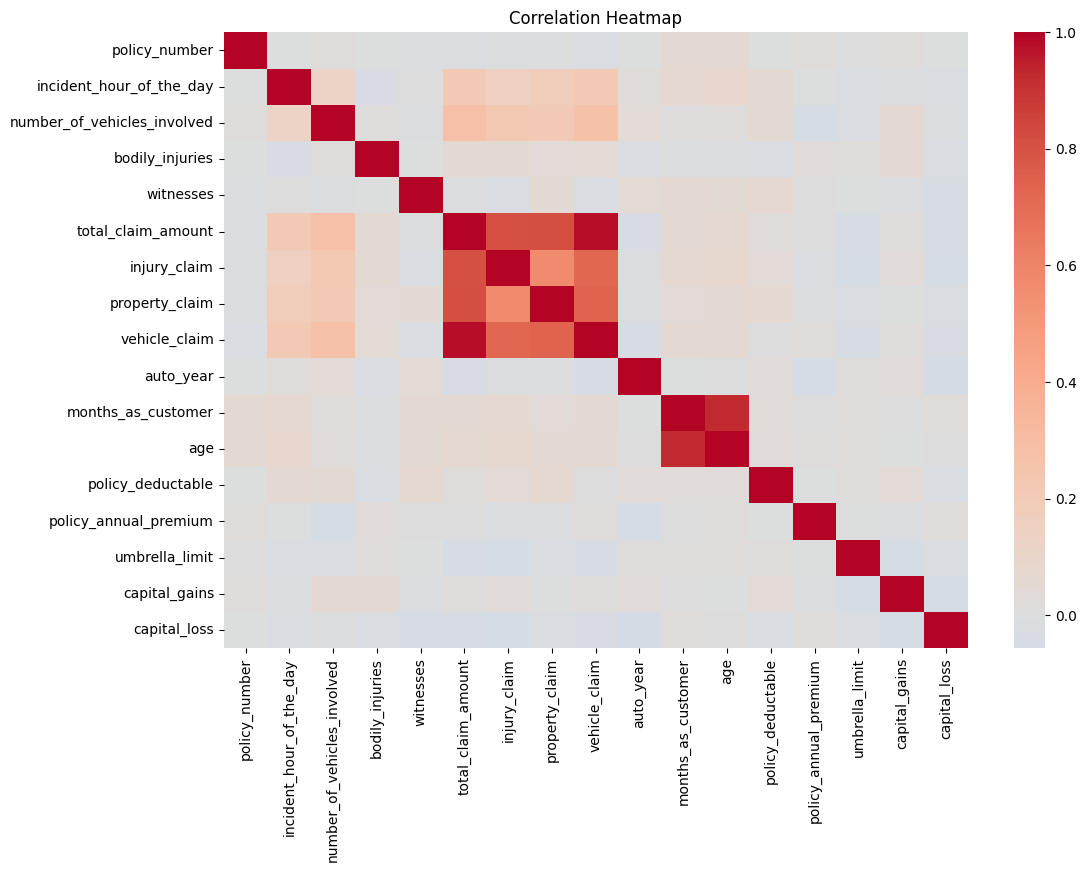

In [9]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## Missing values check

In [10]:
df.isnull().sum()[df.isnull().sum() > 0]

collision_type              178
authorities_contacted        91
property_damage             360
police_report_available     343
fraud_probability          1000
risk_flag                  1000
dtype: int64

## Vehicle check (NHTSA fuzzy match) vs fraud

In [11]:
vehicle_check = pd.read_sql("SELECT * FROM vehicle_check", engine)
merged = df.merge(vehicle_check, on=['auto_make', 'auto_model', 'auto_year'], how='left')
pd.crosstab(merged['model_exists'], merged['fraud_reported'], normalize='index')

fraud_reported,N,Y
model_exists,,
0,0.717131,0.282869
1,0.765020,0.234980


## Next: train fraud classifier (XGBoost/LightGBM) on this cleaned frame